# Basic DC Power Network Example from [1]

[1] Mehrmann, Volker, and Riccardo Morandin. "Structure-preserving discretization for port-Hamiltonian descriptor systems." 
    2019 IEEE 58th Conference on Decision and Control (CDC). IEEE, 2019.

In this example, we have the following example given by the circuit below.

<p align="center">
  <img src="./figures/DCPowerNetwork.png" width="500">
</p>

In [1]:
# Include wrapper for pH modelling in Julia (3 folders up from current file, then ./src/SystemModelling.jl)
include(joinpath(@__DIR__, "..", "..", "..", "src", "SystemModelling.jl"))

using LaTeXStrings
using Plots

using .SystemModellingModule
using .SystemModellingModule.pHModule

# Load config for this example
cfg_DCGen = include("./config/DC_Generator_Mehrmann.jl");

## port-Hamiltonian modelling in Julia

Here, $R_G, R_L, R_R$ are resistances, $L>0$ is an inductor, $C_1,C_2$ are capacitors and $E_G$ is a controlled voltage source. This can be interpreted as a basic representation of a DC generator $(E_G, R_G)$, connected to a load $(R_R)$ with a transmission line [$\pi$-model] $(C_1, C_2, L, R_L)$. By means of the Kirchhoff's circuit laws, this system can be written as the following system of DAEs:

\begin{align*}
L\dot{I} &= -R_LI + V_2 - V_1,\\
C_1\dot{V}_1 &= I - I_G,\\
C_2\dot{V}_2 &= -I-I_R,\\
0 &= -R_GI_G + V_1 + E_G,\\
0 &=-R_RI_R + V_2.
\end{align*}

This system consists of three ordinary differential equations in the dynamic states $(I, V_1, V_2)$ corresponding to the energy storing elements of the system and two differential algebraic equations corresponding to the given inputs and outputs. The states of the system are given by

$$
x = (I, V_1, V_2, I_G, I_R),
$$

such that we can rewrite the system above as

\begin{align*}
E\dot{x} &= (J-R)x + Gu,\\
y &= G^Tx
\end{align*}

with corresponding matrices

1. Skew-symmetric interconnection matrix

$$
J = \left[\begin{matrix}
0.0 & -1.0 &  1.0  & 0.0  & 0.0\\
1.0 & 0.0 & 0.0 & -1.0 & 0.0\\
-1.0 & 0.0 & 0.0 & 0.0 & -1.0\\
0.0 & 1.0 & 0.0 & 0.0 & 0.0\\
0.0 & 0.0 & 1.0 & 0.0 & 0.0
\end{matrix}\right] = -J^T
$$

2. Positive semi definite dissipation matrix

$$
R = \left[\begin{matrix}
R_L & 0.0 &  0.0  & 0.0  & 0.0\\
0.0 & 0.0 & 0.0 & 0.0 & 0.0\\
0.0 & 0.0 & 0.0 & 0.0 & 0.0\\
0.0 & 0.0 & 0.0 & R_G & 0.0\\
0.0 & 0.0 & 0.0 & 0.0 & R_R
\end{matrix}\right] = \mathrm{diag}(R_L, 0.0, 0.0, R_G, R_R) \geq 0
$$

3. Derivative coefficient matrix

$$
E = \left[\begin{matrix}
L & 0.0 &  0.0  & 0.0  & 0.0\\
0.0 & C_1 & 0.0 & 0.0 & 0.0\\
0.0 & 0.0 & C_2 & 0.0 & 0.0\\
0.0 & 0.0 & 0.0 & 0.0 & 0.0\\
0.0 & 0.0 & 0.0 & 0.0 & 0.0
\end{matrix}\right] = \mathrm{diag}(L, C_1, C_2, 0.0, 0.0)
$$

4. Input/Outputs

$$
G = \left[\begin{matrix}
0.0\\
0.0\\
0.0\\
1.0\\
0.0
\end{matrix}\right], u = E_G.
$$

### Parameter values

The following parameters are chosen:

$$
R_L = 0.1, R_G = 6, R_R = 3, L = 2, C_1 = 0.01, C_2 = 0.02.
$$

In [2]:
J = cfg_DCGen.J
R = cfg_DCGen.R
E = cfg_DCGen.E
G = cfg_DCGen.G

# J skew-symmetric
skewSym = SystemModellingModule.utilsModule.is_skewSymmetric(J)

# R p.s.d.
psd = SystemModellingModule.utilsModule.is_positiveSemiDefinite(R)

# Both requirements also checked during initialization of pH System struct
display(skewSym && psd)


true

The total energy stored in the system is given by the Hamiltonian

$$
\mathcal{H}(x) = \frac{1}{2}LI^2 + \frac{1}{2}C_1V_1^2 + \frac{1}{2}C_2V_2^2 = \frac{1}{2}x^TEx
$$

For port-Hamiltonian DAE system, we can use $\texttt{pHDescriptorSystem}$. Here, we need to specify the way we model the system, namely either in 

1. energy-variables (:x_states):

or

2. co-energy variables (:z_states)

For a general pH system with quadratic Hamiltonian

\begin{align*}
E\dot{x} &= (J-R)\texttt{Qe}x + Gu,\\
y &= G^T\texttt{Qe}x,\\
\mathcal{H}(x) &= \frac{1}{2}x^T\cdot\texttt{QH}\cdot x,
\end{align*}

the matrices $\texttt{Qe}$ and $\texttt{QH}$ also need to be provided. When considering

1. :x_states, i.e. energy-based modelling, it is necessary, that $\texttt{Qe} = \texttt{QH}$. 

2. :z_states, i.e. co-energy-based modelling, it is necessary, that $\texttt{Qe} = I$ and $\texttt{QH}$ needs to be aligned to the energy stored in the system.

In this example, the states is given by a mixture of voltages and currents in the system that correspond to the co-energy variables, so we must set the representation and $\texttt{Qe}, \texttt{QH}$ matrices as follows:

In [3]:
sys_rep = cfg_DCGen.rep # Co-energy based modelling
Qe = cfg_DCGen.Qe   # Identity
QH = cfg_DCGen.QH;   # E

Now, we initialized all the needed objects for our port-Hamiltonian DAE struct.

In [4]:
sys = pHDescriptorSystem(E, J, R, Qe, G; QH=QH, rep=sys_rep);

We can now initialize a $\texttt{DescriptorSimulator}$ in which we must specify the system to be simulated, i.e. $\texttt{pHDescriptorSystem}$, a step size $\texttt{dt}$ and a simulation method. Currently there are only two available, :Gauss1 and :Gauss2, corresponding to the Gauss-Legendre collocation methods with 1 and 2 stages. For index-1-like systems, these methods are of order 2 and 4, respectively. We can check the index of the system by running the function 

- is_index1_like(sys::pHDescriptorSystem; atol=1e-10)

The index of a system determines the possibility of solving the system. For systems of (differentiation) index 1, there is no need to differentiate the system equations further to get a solution. We can directly apply our solver if the system is of index 1.

In [5]:
simulator = DescriptorSimulator(sys, cfg_DCGen.dt, :Gauss1)

is_index1_like(sys; atol=1e-10)

true

The $\texttt{DescriptorSimulator}$ struct has a function $\texttt{simulate}$, that needs

- A corresponding system simulator struct $\texttt{DescriptorSimulator}$
- An initial condition for the system $x_0$
- An input function $u$
- A time interval $[t_0, t_f]$

In this example, we first consider an uncontrolled system, i.e. $u(t) \equiv 0$ with initial condition

$$
x_0 = [1.83, -5.66, -5.48, 1.83, -1.83]^T.
$$

This initial condition will reproduce the results of the uncontrolled numerical experiments in [1]. We can also use random initial conditions to see other results that are asymptotically stable. We can simulate the example as follows.

In [6]:
t, states_uncontrolled, output_uncontrolled = simulate(simulator, cfg_DCGen.x0_nocontrol, cfg_DCGen.u_nocontrol, cfg_DCGen.tspan);

The simulate function returns: Time interval $t$, states $x$ and output $y$. We can plot the solutions using the functions

- plot_states: Plots only the states
- plot_energy: Plots only the energy in the system (Hamiltonian)
- plot_results: Plots both states and energy stored in the system, can specify boolean parameter $\texttt{separate}$ to plot results in different subplots.

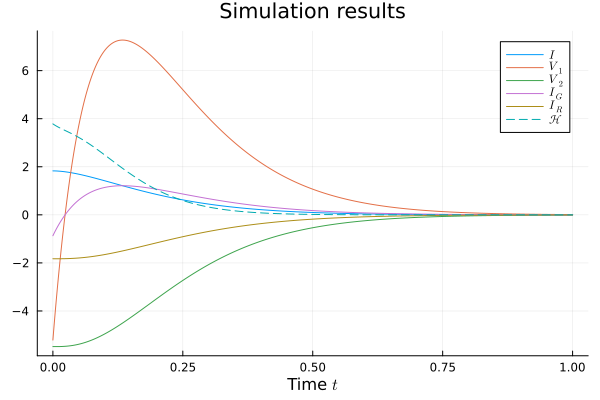

In [7]:
plot_results(t, states_uncontrolled; sys=sys, state_labels=[L"$I$", L"$V_1$", L"$V_2$", L"$I_G$", L"$I_R$"], separate=false)

"Random initial condition: [0.45979106120096314, 1.176039221613453, -0.7508754232855426, -0.9789295419407108, -0.39519127346508565]"

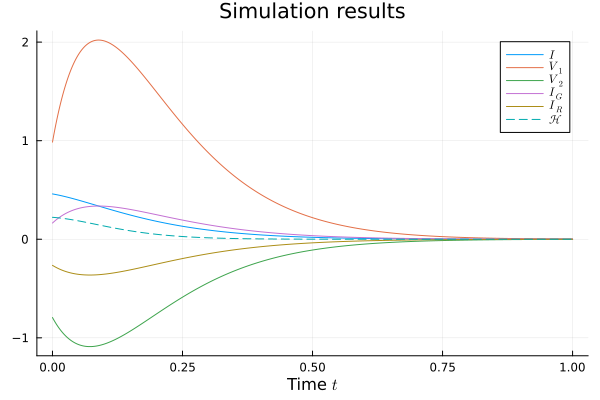

In [8]:
x0_rng = randn(5)   # Random initial conditions
display("Random initial condition: $x0_rng")
t, states_rngx0, output_rngx0= simulate(simulator, x0_rng, cfg_DCGen.u_nocontrol, cfg_DCGen.tspan);
plot_results(t, states_rngx0; sys=sys, state_labels=[L"$I$", L"$V_1$", L"$V_2$", L"$I_G$", L"$I_R$"], separate=false)

## Controlling the network

We now follow [1] and interpret $R_R$ as a consumer that requires a fixed amount of power $P=R_RI_R^2$. We would like to control the voltage of the generator $u=E_G$, so that the state of the system will converge to an equilibrium

$$
I_R^\ast := -\sqrt{\frac{P}{R_R}}.
$$

At equilibrium, the derivatives of the states are set to zero, i.e. the dynamics of the system (equations 1-3) reduce to

\begin{align*}
L\dot{I}^\ast \stackrel{!}{=} 0 &= -R_LI^\ast + V_2^\ast - V_1^\ast,\\
C_1\dot{V_1}^\ast \stackrel{!}{=} 0 &= I^\ast - I_G^\ast,\\
C_2\dot{V_2}^\ast \stackrel{!}{=} 0 &= -I^\ast - I_R^\ast.
\end{align*}

The power output $P$ can also be written in terms of $V_2$:

$$
P = V_2\cdot I_R^\ast \implies V_2^\ast = -\sqrt{P\cdot R_R}
$$

Since $I^\ast = I_G = I_R^\ast$, we also have

$$
I_G^\ast = I^\ast = \sqrt{\frac{P}{R_R}}
$$

From the equilibrium dyanmics above, we get the final equilibrium value for $V_1^\ast$, namely

$$
V_1^\ast = V_2^\ast - R_R\cdot I^\ast = -\frac{\sqrt{P}}{\sqrt{R_R}}(R_R - R_L).
$$

The complete desired state can now be written in terms of the desired power delivery $P$:

$$
x^\ast = -\sqrt{\frac{P}{R_R}}\left[\begin{matrix}
1\\
-R_R - R_L\\
-R_R\\
1\\
-1
\end{matrix}\right]
$$

The control that can reach this equilibrium can be derived by the first DAE arising in the pHDAE formulation, i.e.

\begin{align*}
0 &= -R_GI_G^\ast + V_1^\ast + u^\ast\\
\iff u^\ast &= R_GI_G^\ast - V_1^\ast\\
\iff u^\ast &= R_G\sqrt{\frac{P}{R_R}} + \sqrt{\frac{P}{R_R}}(R_R - R_L)\\
\iff u^\ast &= \frac{\sqrt{P}}{\sqrt{R_R}}\cdot(R_G + R_R - R_L).
\end{align*}

The following numerical values arise in our example:

In [9]:
P = 10;
x_ast = -sqrt(P/R_R).*vec([1, -R_R-R_L, -R_R, 1, -1]);
u_ast = sqrt(P/R_R)*(R_G + R_R - R_L);

display("Desired state $x_ast")
display("Desired control $u_ast")

"Desired state [-1.8257418583505538, 5.659799760886717, 5.477225575051661, -1.8257418583505538, 1.8257418583505538]"

"Desired control 16.249102539319928"

Instead of using this constant $u^\ast$, we will use a ramp-up function to simulate the ramp up of the DC generator to match the desired DC voltage input of $u^\ast$. For this we use the following control function 

$$
\hat{u}(t) = u^\ast\cdot\left(\frac{1}{\pi}\arctan\left(5\left(t-\frac{1}{2}\right)\right) + \frac{1}{2}\right).
$$

Additionally, the simulation time will be increased to three seconds.

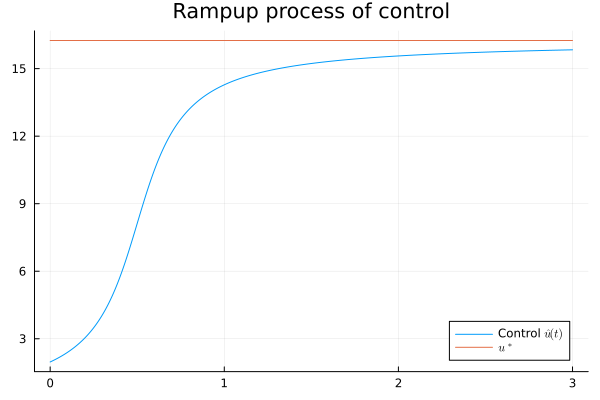

In [10]:
timespan = 0:cfg_DCGen.dt:3

u_ramp(t) = u_ast .* (atan.(5*(t .- 0.5))./pi .+ 0.5)
u_control = u_ramp(timespan)

plot(timespan, u_control, label=L"Control $\hat{u}(t)$", title="Rampup process of control")
plot!(timespan, u_ast*ones(size(u_control)), label=L"$u^\ast$")

With all these values determined, we can simulate the whole power network with this control input to reach the desired equilibrium $x^\ast$.

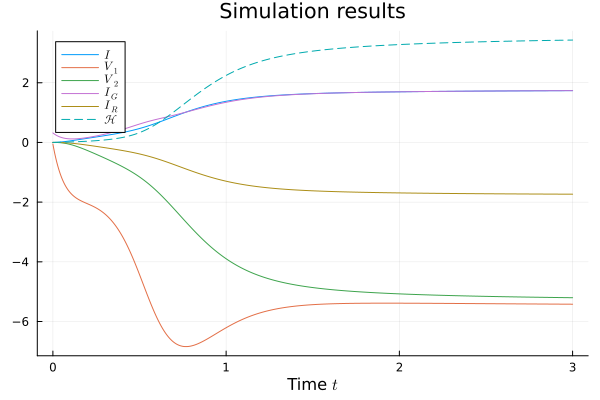

In [11]:
t, states_controlled, output_controlled = simulate(simulator, zeros(5), cfg_DCGen.u_ramp, timespan);

plot_results(t, states_controlled; sys=sys, state_labels=[L"$I$", L"$V_1$", L"$V_2$", L"$I_G$", L"$I_R$"], separate=false)

Finally, we can monitor the power delivered in the system and verify the power balance equation

$$
\dot{\mathcal{H}} = -R_LI^2 - R_GI_G^2 - R_RI_R^2 + I_G u
$$

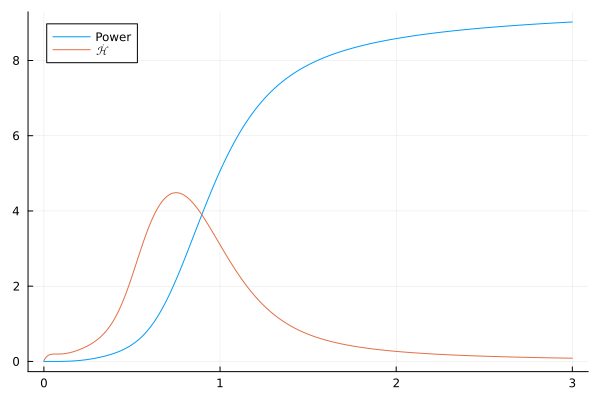

In [32]:
I_R = states_controlled[5, :];

power_monitoring = R_R*I_R.^2;

Hdot = -R_L*states_controlled[1, :].^2 - R_G*states_controlled[4, :].^2 - R_R*states_controlled[5, :].^2 + states_controlled[4, :].*u_control

plot(timespan, power_monitoring, label="Power")
plot!(timespan, Hdot, label=L"$\dot{\mathcal{H}}$")
